# Transmission Line Fault Detection Using Machine Learning




## 1. Import Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


## 2. Load the Dataset

In [29]:
df = pd.read_csv(
    "/kaggle/input/datasets/esathyaprakash/electrical-fault-detection-and-classification/classData.csv"
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (7861, 10)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


## 3. Inspect the Dataset

In [30]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()


Columns:
['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


## 4. Create the Fault Target

In [31]:
df['Fault'] = (
    (df['G'] == 1) |
    (df['C'] == 1) |
    (df['B'] == 1) |
    (df['A'] == 1)
).astype(int)

print(df['Fault'].value_counts())

print("\n0 = No Fault")
print("1 = Fault")


Fault
1    5496
0    2365
Name: count, dtype: int64

0 = No Fault
1 = Fault


## 5. Fault Distribution

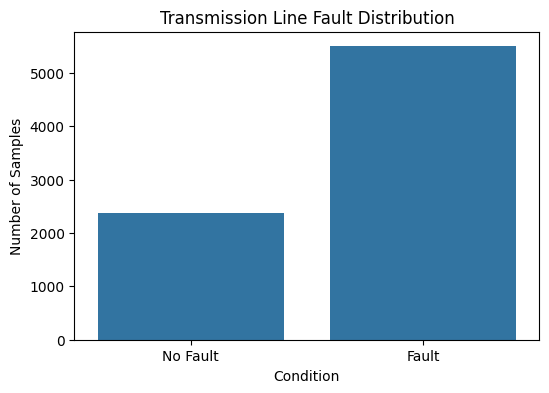

In [32]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Fault')

plt.xticks([0, 1], ['No Fault', 'Fault'])
plt.xlabel('Condition')
plt.ylabel('Number of Samples')
plt.title('Transmission Line Fault Distribution')

plt.show()


## 6. Select Electrical Features

In [33]:
features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

X = df[features]
y = df['Fault']

print("Input features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)


Input features: ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X shape: (7861, 6)
y shape: (7861,)


## 7. Basic Exploratory Analysis

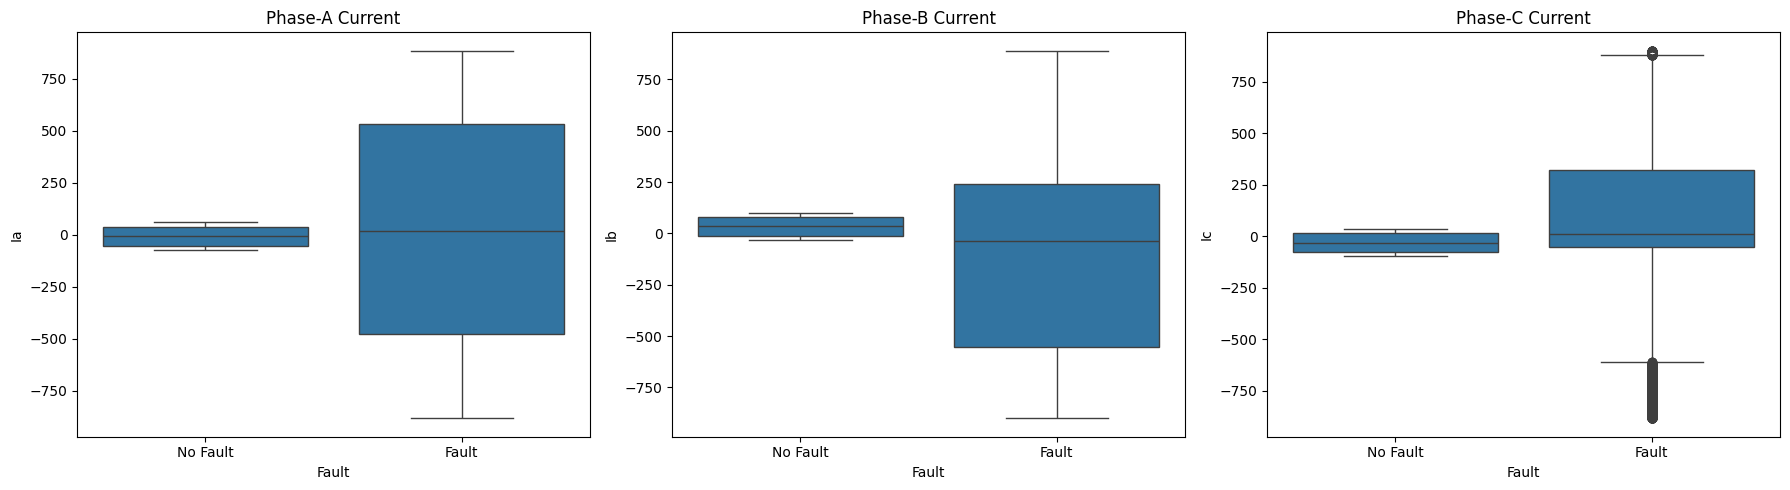

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Fault', y='Ia', ax=axes[0])
axes[0].set_title('Phase-A Current')
axes[0].set_xticklabels(['No Fault', 'Fault'])

sns.boxplot(data=df, x='Fault', y='Ib', ax=axes[1])
axes[1].set_title('Phase-B Current')
axes[1].set_xticklabels(['No Fault', 'Fault'])

sns.boxplot(data=df, x='Fault', y='Ic', ax=axes[2])
axes[2].set_title('Phase-C Current')
axes[2].set_xticklabels(['No Fault', 'Fault'])

plt.tight_layout()
plt.show()


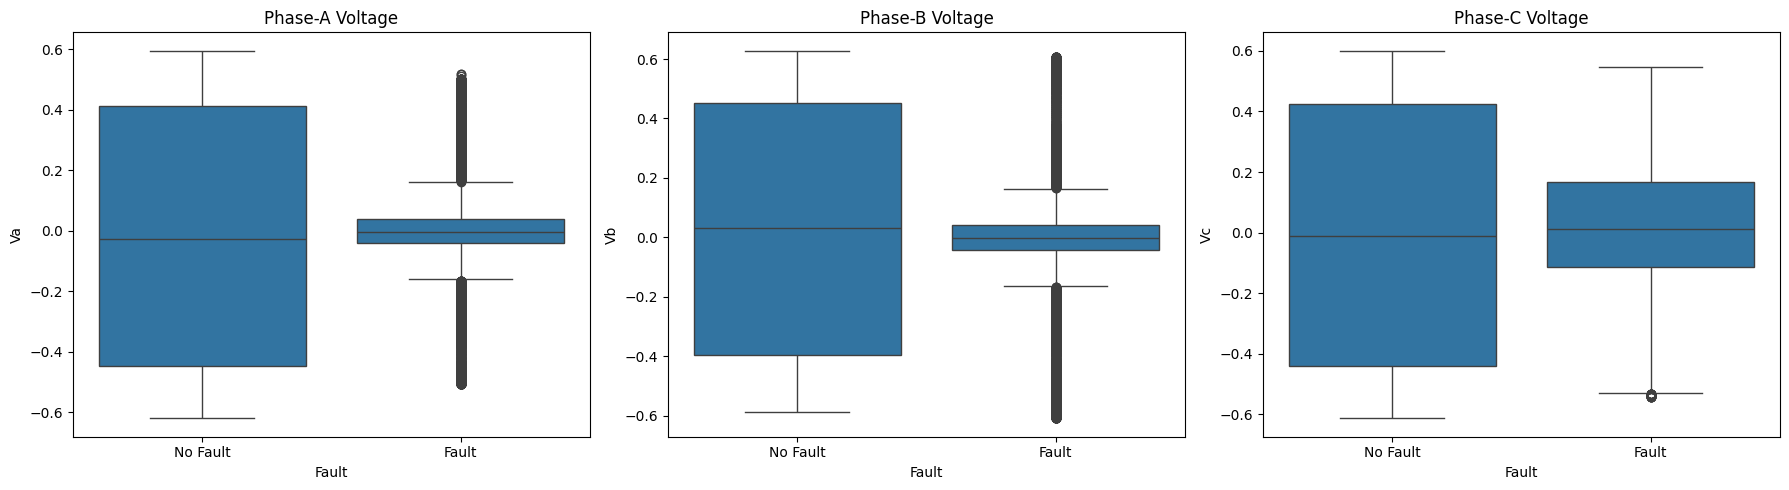

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Fault', y='Va', ax=axes[0])
axes[0].set_title('Phase-A Voltage')
axes[0].set_xticklabels(['No Fault', 'Fault'])

sns.boxplot(data=df, x='Fault', y='Vb', ax=axes[1])
axes[1].set_title('Phase-B Voltage')
axes[1].set_xticklabels(['No Fault', 'Fault'])

sns.boxplot(data=df, x='Fault', y='Vc', ax=axes[2])
axes[2].set_title('Phase-C Voltage')
axes[2].set_xticklabels(['No Fault', 'Fault'])

plt.tight_layout()
plt.show()


## 8. Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 6288
Testing samples : 1573


## 9. Train the Random Forest Model

In [37]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


## 10. Evaluate on Test Data

In [40]:
y_pred_clean = model.predict(X_test)

clean_accuracy = accuracy_score(
    y_test,
    y_pred_clean
)

print(f" Test Accuracy: {clean_accuracy * 100:.2f}%")


 Test Accuracy: 100.00%


In [42]:
X_test_noisy = X_test.copy()

np.random.seed(42)

noise_level = 0.02

for column in X_test_noisy.columns:
    noise = np.random.normal(
        loc=0,
        scale=noise_level * X_test_noisy[column].std(),
        size=len(X_test_noisy)
    )

    X_test_noisy[column] = X_test_noisy[column] + noise




## 12. Evaluate on Test Data

In [43]:
y_pred_noisy = model.predict(X_test_noisy)

noisy_accuracy = accuracy_score(
    y_test,
    y_pred_noisy
)

print(f"Test Accuracy: {noisy_accuracy * 100:.2f}%")


Test Accuracy: 95.99%


In [44]:
print(classification_report(
    y_test,
    y_pred_noisy,
    target_names=['No Fault', 'Fault']
))


              precision    recall  f1-score   support

    No Fault       1.00      0.87      0.93       473
       Fault       0.95      1.00      0.97      1100

    accuracy                           0.96      1573
   macro avg       0.97      0.93      0.95      1573
weighted avg       0.96      0.96      0.96      1573



## 13. Confusion Matrix 

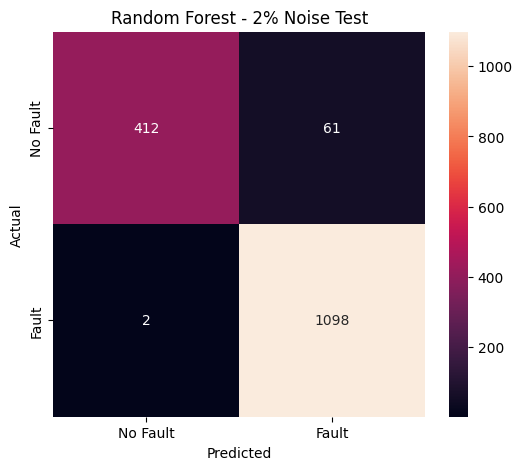

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred_noisy
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Fault', 'Fault'],
    yticklabels=['No Fault', 'Fault']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - 2% Noise Test')

plt.show()


## 14. Feature Importance

In [46]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

display(importance)


,Feature,Importance
0,Ia,0.320580
1,Ib,0.277444
2,Ic,0.155889
3,Va,0.093858
5,Vc,0.084571
4,Vb,0.067659


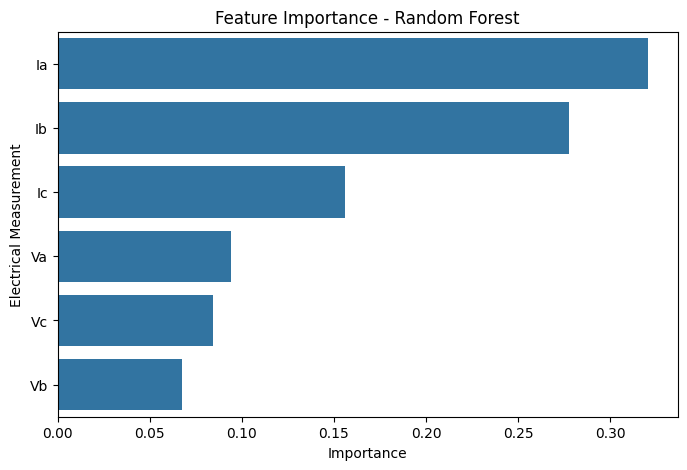

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.xlabel('Importance')
plt.ylabel('Electrical Measurement')
plt.title('Feature Importance - Random Forest')

plt.show()


## 15. Prediction on an Unseen Test Sample

In [48]:
sample = X_test_noisy.iloc[[0]]
actual = y_test.iloc[0]

predicted = model.predict(sample)[0]
probability = model.predict_proba(sample)[0]

print("Actual   :", "FAULT" if actual == 1 else "NO FAULT")
print("Predicted:", "FAULT" if predicted == 1 else "NO FAULT")

print("\nModel Probability:")
print(f"No Fault: {probability[0] * 100:.2f}%")
print(f"Fault   : {probability[1] * 100:.2f}%")


Actual   : FAULT
Predicted: FAULT

Model Probability:
No Fault: 0.00%
Fault   : 100.00%


## 16. Save the Trained Model

In [49]:
import joblib

joblib.dump(
    model,
    'transmission_line_fault_model.pkl'
)

print("Model saved as: transmission_line_fault_model.pkl")


Model saved as: transmission_line_fault_model.pkl
